# 01 — EDA & Preprocessing

**Goal**: Load the SMS Spam Collection, explore its structure, clean the text, and prepare TF-IDF features for modeling.

**Author**: Shared (Person A & B)

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("All imports OK")

All imports OK


In [2]:
# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
print("NLTK resources ready")

NLTK resources ready


## 2. Load Data

In [3]:
# Load the TSV file (no header, tab-separated)
import csv
df = pd.read_csv('../data/SMSSpamCollection', sep='\t', header=None, names=['label', 'message'], quoting=csv.QUOTE_NONE)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (5574, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 3. Initial Exploration

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5574 non-null   str  
 1   message  5574 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


label
ham     4827
spam     747
Name: count, dtype: int64

Spam ratio: 13.40%


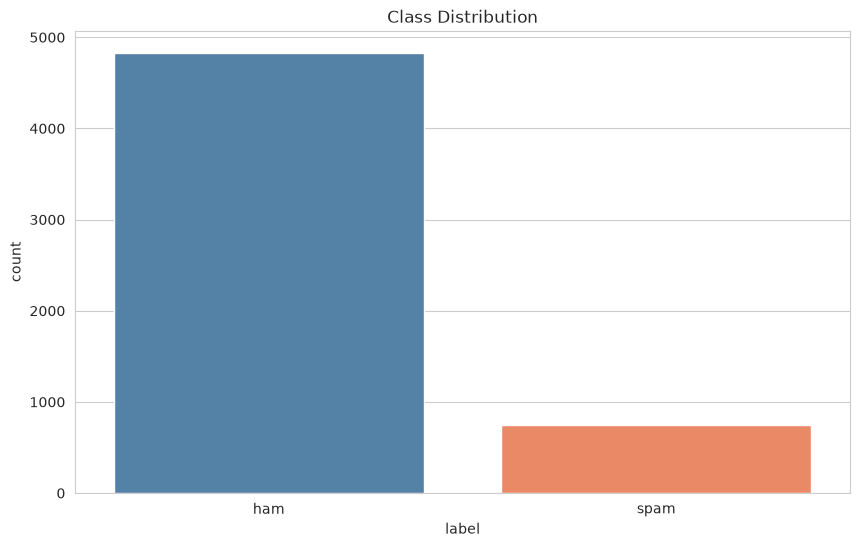

In [5]:
# Class distribution
print(df['label'].value_counts())
print(f"\nSpam ratio: {df['label'].value_counts(normalize=True)['spam']:.2%}")

sns.countplot(data=df, x='label', hue='label', palette={'ham': 'steelblue', 'spam': 'coral'}, legend=False)
plt.title('Class Distribution')
plt.show()

In [6]:
# Encode label: ham=0, spam=1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
df[['label', 'label_num']].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


## 4. Text Analysis

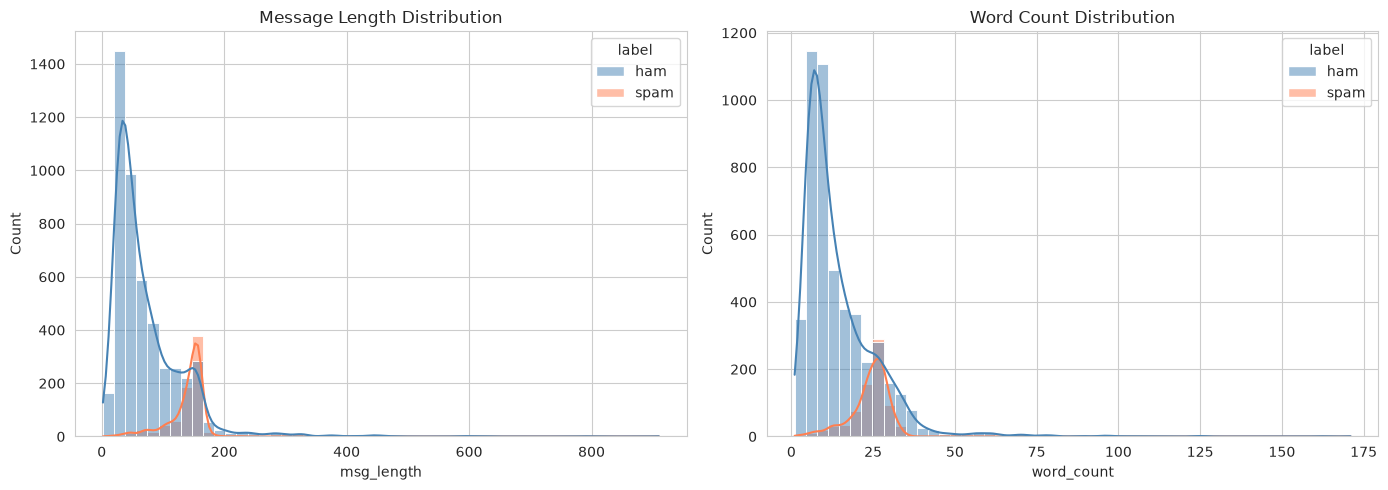

Ham  - avg length: 71.5 chars
Spam - avg length: 138.7 chars


In [7]:
# Message length (characters)
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='msg_length', hue='label', bins=50, kde=True, ax=axes[0], palette={'ham': 'steelblue', 'spam': 'coral'})
axes[0].set_title('Message Length Distribution')
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True, ax=axes[1], palette={'ham': 'steelblue', 'spam': 'coral'})
axes[1].set_title('Word Count Distribution')
plt.tight_layout()
plt.show()

print(f"Ham  - avg length: {df[df['label']=='ham']['msg_length'].mean():.1f} chars")
print(f"Spam - avg length: {df[df['label']=='spam']['msg_length'].mean():.1f} chars")

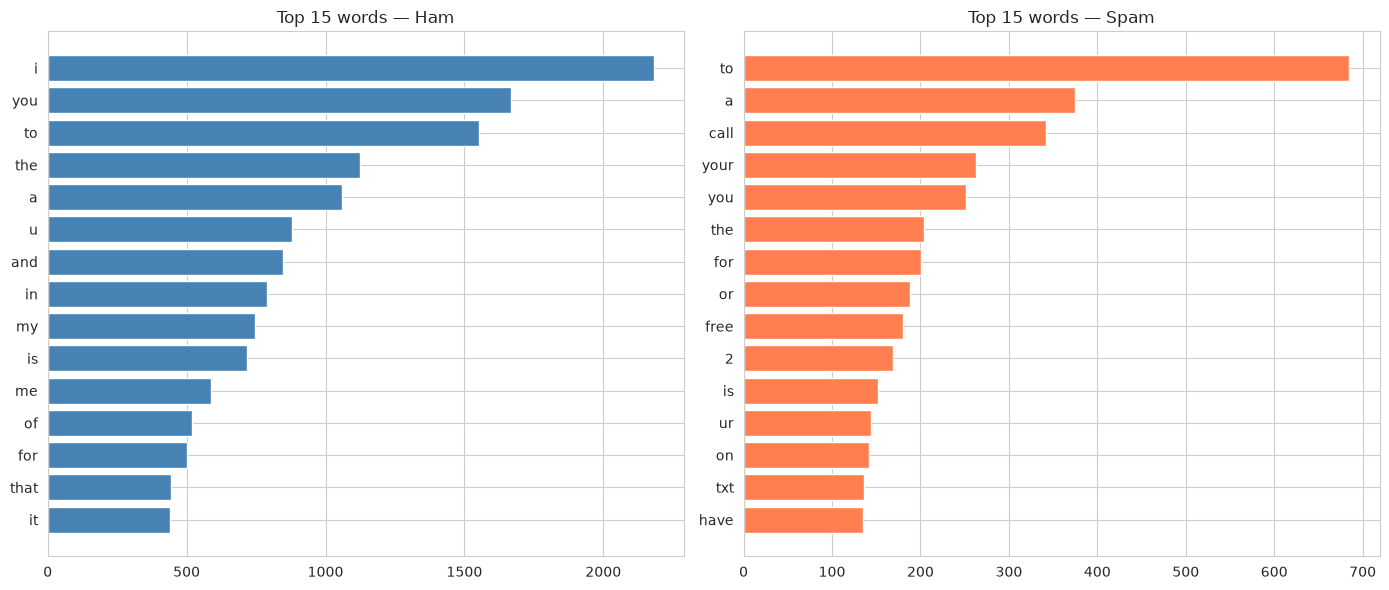

In [8]:
# Most common words in ham vs spam
from collections import Counter

def get_top_words(series, n=20):
    words = ' '.join(series).lower().split()
    return Counter(words).most_common(n)

ham_words = get_top_words(df[df['label']=='ham']['message'])
spam_words = get_top_words(df[df['label']=='spam']['message'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([w for w,c in ham_words[:15]][::-1], [c for w,c in ham_words[:15]][::-1], color='steelblue')
axes[0].set_title('Top 15 words — Ham')
axes[1].barh([w for w,c in spam_words[:15]][::-1], [c for w,c in spam_words[:15]][::-1], color='coral')
axes[1].set_title('Top 15 words — Spam')
plt.tight_layout()
plt.show()

## 5. Text Preprocessing

Cleaning pipeline: lowercase → remove punctuation → remove stopwords → stemming

In [9]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation & non-alphabetic
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and stem
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
print("Cleaning done")
print(f"\nOriginal:  {df['message'].iloc[0]}")
print(f"Cleaned:   {df['clean_message'].iloc[0]}")

Cleaning done

Original:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:   go jurong point crazi avail bugi great world la buffet cine got amor wat


## 6. Train / Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(f"Train spam ratio: {y_train.mean():.2%}")
print(f"Test spam ratio:  {y_test.mean():.2%}")

Train size: 4459
Test size:  1115
Train spam ratio: 13.41%
Test spam ratio:  13.36%


## 7. TF-IDF Vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (4459, 3000)
TF-IDF matrix shape (test):  (1115, 3000)
Vocabulary size: 3000


In [12]:
# Quick peek at top TF-IDF features
feature_names = tfidf.get_feature_names_out()
# Sum TF-IDF scores per feature across the training set
sums = X_train_tfidf.sum(axis=0).A1
top_idx = sums.argsort()[::-1][:15]
print("Top 15 features by total TF-IDF score:")
for idx in top_idx:
    print(f"  {feature_names[idx]:20s}  {sums[idx]:.2f}")

Top 15 features by total TF-IDF score:
  im                    85.10
  ok                    79.17
  come                  66.23
  ill                   55.70
  got                   54.67
  dont                  53.94
  ltgt                  53.18
  know                  52.43
  ur                    50.36
  want                  50.22
  good                  50.05
  time                  49.42
  like                  47.65
  love                  44.98
  home                  43.38


## 8. Save for Model Notebooks

In [13]:
import joblib

joblib.dump(X_train_tfidf, '../data/X_train_tfidf.pkl')
joblib.dump(X_test_tfidf,  '../data/X_test_tfidf.pkl')
joblib.dump(y_train,       '../data/y_train.pkl')
joblib.dump(y_test,        '../data/y_test.pkl')
joblib.dump(tfidf,         '../data/tfidf_vectorizer.pkl')
print("All objects saved to data/")

All objects saved to data/
